In [1]:
import tensorflow as tf
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [2]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.35),

    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)

model.save("cnn_fashion_mnist.keras")
np.save("cnn_history.npy", history.history)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7733 - loss: 0.6186 - val_accuracy: 0.8593 - val_loss: 0.3829 - learning_rate: 0.0010
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8560 - loss: 0.4012 - val_accuracy: 0.8708 - val_loss: 0.3513 - learning_rate: 0.0010
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8724 - loss: 0.3550 - val_accuracy: 0.8913 - val_loss: 0.2971 - learning_rate: 0.0010
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8842 - loss: 0.3199 - val_accuracy: 0.8953 - val_loss: 0.2872 - learning_rate: 0.0010
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8934 - loss: 0.2979 - val_accuracy: 0.9044 - val_loss: 0.2598 - learning_rate: 0.0010
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8969 - loss: 0.2840 - val_accuracy: 0.9032 - val_loss: 0.2604 - learning_rate: 0.0010
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8996 - loss: 0.2686 -

In [5]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Точність на тестових даних: {test_accuracy:.4f}")
print(f"Втрати на тестових даних: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9218 - loss: 0.2233
Точність на тестових даних: 0.9218
Втрати на тестових даних: 0.2233


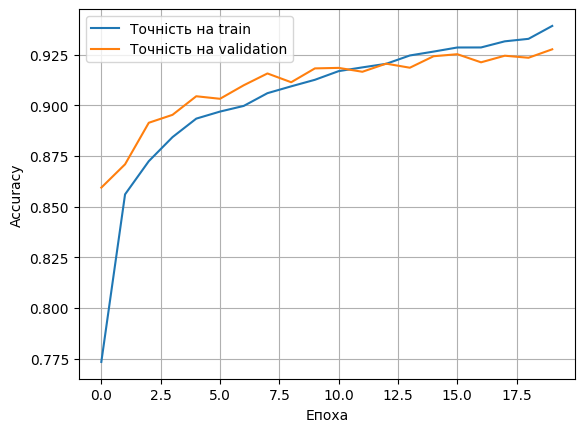

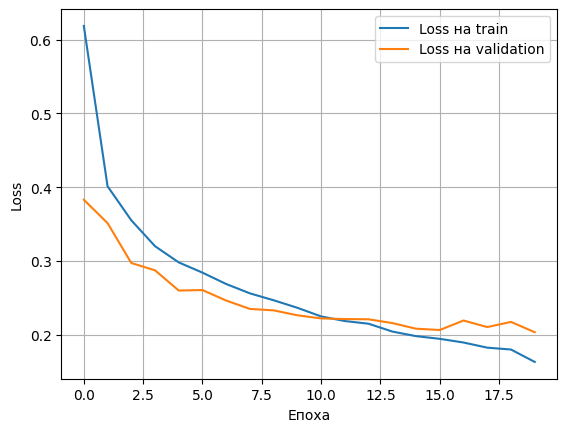

In [6]:
plt.plot(history.history["accuracy"], label="Точність на train")
plt.plot(history.history["val_accuracy"], label="Точність на validation")
plt.xlabel("Епоха")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history["loss"], label="Loss на train")
plt.plot(history.history["val_loss"], label="Loss на validation")
plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


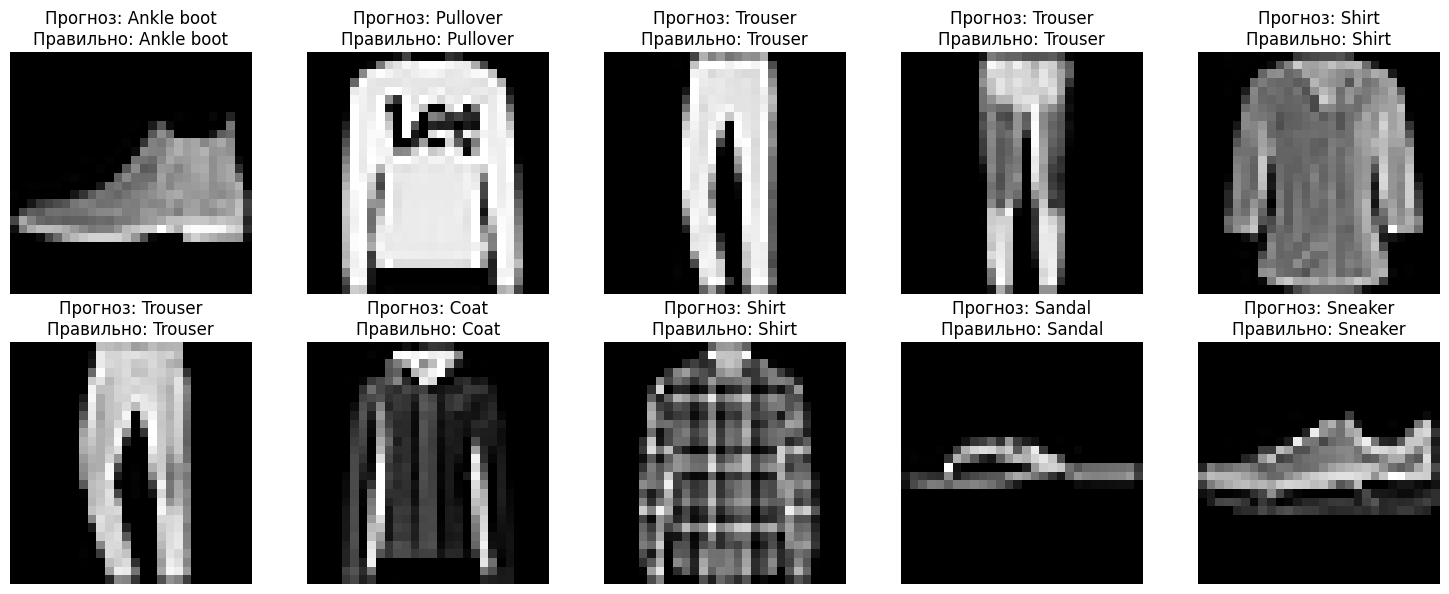

In [7]:
predictions = model.predict(X_test)

plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    predicted_class = np.argmax(predictions[i])
    true_class = y_test[i]

    plt.title(
        f"Прогноз: {class_names[predicted_class]}\nПравильно: {class_names[true_class]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
'''
Було створено згорткову нейронну мережу для класифікації зображень одягу з датасету Fashion-MNIST.

Мережа складається з кількох згорткових шарів Conv2D, шарів MaxPooling2D для зменшення розмірності та Dropout для зменшення перенавчання.

Після навчання модель показала високу точність на тестових даних. Згорткова нейронна мережа працює краще за звичайну dense-мережу,
оскільки вона враховує просторову структуру зображень.
'''

'\nБуло створено згорткову нейронну мережу для класифікації зображень одягу з датасету Fashion-MNIST.\n\nМережа складається з кількох згорткових шарів Conv2D, шарів MaxPooling2D для зменшення розмірності та Dropout для зменшення перенавчання.\n\nПісля навчання модель показала високу точність на тестових даних. Згорткова нейронна мережа працює краще за звичайну dense-мережу,\nоскільки вона враховує просторову структуру зображень.\n'

In [9]:
import tensorflow as tf
from keras.datasets import fashion_mnist
from keras.applications import VGG16
from keras import models
from keras import layers
from keras.optimizers import Adam
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

def preprocess_images(images):
    images = images[..., tf.newaxis]
    images = tf.image.resize(images, (96, 96))
    images = tf.image.grayscale_to_rgb(images)
    return images

X_train_vgg = preprocess_images(X_train)
X_test_vgg = preprocess_images(X_test)

vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

vgg_base.trainable = False

In [10]:
model = models.Sequential([
   vgg_base,
   layers.Flatten(),
   layers.Dense(512, activation="relu"),
   layers.Dropout(0.5),
   layers.Dense(256, activation="relu"),
   layers.Dropout(0.4),
   layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,208,394 (65.64 MB)

 Trainable params: 2,493,706 (9.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
history = model.fit(
    X_train_vgg,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 93s 213ms/step - accuracy: 0.3753 - loss: 1.8342 - val_accuracy: 0.7697 - val_loss: 0.9829
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 69s 184ms/step - accuracy: 0.6734 - loss: 1.0124 - val_accuracy: 0.8067 - val_loss: 0.6321
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 69s 184ms/step - accuracy: 0.7446 - loss: 0.7658 - val_accuracy: 0.8255 - val_loss: 0.5212
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 69s 183ms/step - accuracy: 0.7810 - loss: 0.6495 - val_accuracy: 0.8368 - val_loss: 0.4674
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 69s 184ms/step - accuracy: 0.7979 - loss: 0.5880 - val_accuracy: 0.8458 - val_loss: 0.4351
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 69s 184ms/step - accuracy: 0.8164 - loss: 0.5403 - val_accuracy: 0.8506 - val_loss: 0.4136
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 69s 184ms/step - accuracy: 0.8246 - loss: 0.5093 - val_accuracy: 0.8577 - val_loss: 0.3966
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 69s 183ms/step - accuracy: 0.8342 - loss: 0

In [12]:
vgg_base.trainable = True

for layer in vgg_base.layers:
    layer.trainable = False

for layer in vgg_base.layers:
    if "block5" in layer.name:
        layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
history = model.fit(
    X_train_vgg,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 124s 514ms/step - accuracy: 0.8877 - loss: 0.3174 - val_accuracy: 0.9012 - val_loss: 0.2683
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 70s 373ms/step - accuracy: 0.9022 - loss: 0.2784 - val_accuracy: 0.9081 - val_loss: 0.2520
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 70s 375ms/step - accuracy: 0.9113 - loss: 0.2503 - val_accuracy: 0.9143 - val_loss: 0.2369
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 70s 373ms/step - accuracy: 0.9191 - loss: 0.2309 - val_accuracy: 0.9189 - val_loss: 0.2264
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 70s 374ms/step - accuracy: 0.9260 - loss: 0.2147 - val_accuracy: 0.9193 - val_loss: 0.2260
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 70s 375ms/step - accuracy: 0.9296 - loss: 0.2005 - val_accuracy: 0.9210 - val_loss: 0.2200
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 70s 374ms/step - accuracy: 0.9352 - loss: 0.1862 - val_accuracy: 0.9230 - val_loss: 0.2104
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 70s 374ms/step - accuracy: 0.9384 - loss: 

In [14]:
model.save("vgg16_fashion_mnist.keras")
np.save("vgg_history.npy", history.history)

In [15]:
test_loss, test_accuracy = model.evaluate(X_test_vgg, y_test)

print(f"Точність на тестових даних: {test_accuracy:.4f}")
print(f"Втрати на тестових даних: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9211 - loss: 0.2308
Точність на тестових даних: 0.9211
Втрати на тестових даних: 0.2308


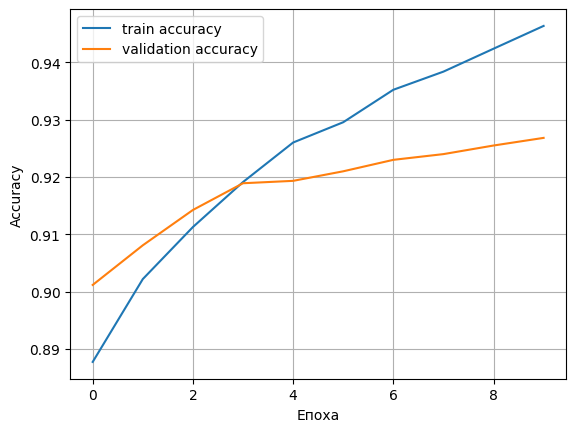

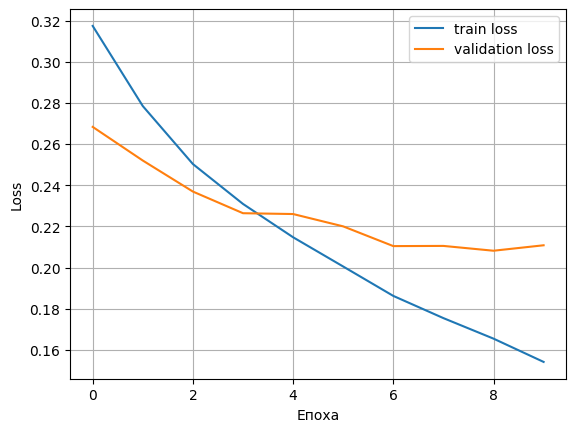

In [16]:
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Епоха")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
'''
Було створено згорткову нейронну мережу, яка використовує VGG16 як згорткову основу.

Оскільки VGG16 працює з RGB-зображеннями, зображення Fashion-MNIST були змінені з формату 28×28×1
на 48x48x3.

Згорткова основа VGG16 була заморожена, тобто її ваги не навчалися. До неї було додано власний
класифікатор із Dense-шаром, Dropout та вихідним шаром на 10 класів.

Модель була навчена на датасеті Fashion-MNIST і протестована на тестовій вибірці.
'''

'\nБуло створено згорткову нейронну мережу, яка використовує VGG16 як згорткову основу.\n\nОскільки VGG16 працює з RGB-зображеннями, зображення Fashion-MNIST були змінені з формату 28×28×1\nна 48x48x3.\n\nЗгорткова основа VGG16 була заморожена, тобто її ваги не навчалися. До неї було додано власний\nкласифікатор із Dense-шаром, Dropout та вихідним шаром на 10 класів.\n\nМодель була навчена на датасеті Fashion-MNIST і протестована на тестовій вибірці.\n'